In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers

In [ ]:
data_train_path  = "C:\\Users\\manis\\OneDrive\\Desktop\\food_image _classifi\\train"
data_test_path = "C:\\Users\\manis\\OneDrive\\Desktop\\food_image _classifi\\test"
data_validation_path = "C:\\Users\\manis\\OneDrive\\Desktop\\food_image _classifi\\validation"

In [ ]:
img_height = 200
img_width = 200

In [19]:
data_train = tf.keras.utils.image_dataset_from_directory(
    data_train_path,
    shuffle=True,
    image_size=(img_height, img_width),
    batch_size=32,
    validation_split=False
)

Found 161 files belonging to 11 classes.


In [20]:
data_cat = data_train.class_names
print(data_cat)

['Bread', 'Dairy product', 'Dessert', 'Egg', 'Fried food', 'Meat', 'Noodles- pasta', 'Rice', 'Soup', 'Vegetable-Fruits', 'seafood']


In [21]:
data_cat

['Bread',
 'Dairy product',
 'Dessert',
 'Egg',
 'Fried food',
 'Meat',
 'Noodles- pasta',
 'Rice',
 'Soup',
 'Vegetable-Fruits',
 'seafood']

In [37]:
data_validation = tf.keras.utils.image_dataset_from_directory(
    data_validation_path,
    image_size=(img_height, img_width),
    batch_size=32,
    shuffle=False,
    validation_split=False
    
)

Found 161 files belonging to 11 classes.


In [39]:
data_test = tf.keras.utils.image_dataset_from_directory(
    data_test_path,
    image_size=(img_height,img_width),
    shuffle=False,
    batch_size=32,
    validation_split=False
)

Found 162 files belonging to 11 classes.


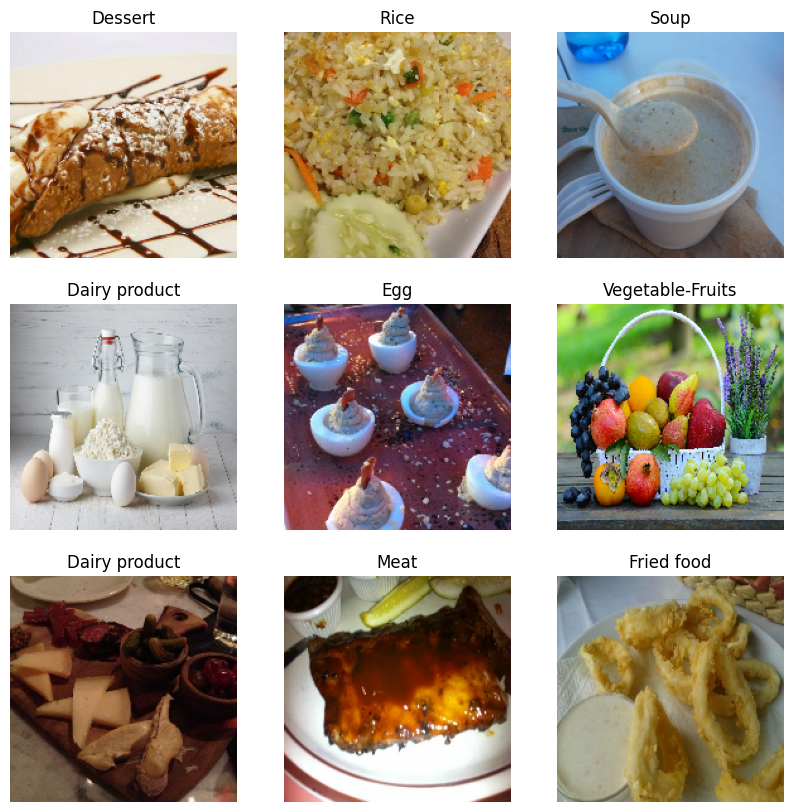

In [23]:
plt.figure(figsize=(10,10))

for images, labels in data_train.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(data_cat[labels[i]])
        plt.axis("off")

In [24]:
from tensorflow.keras.models import Sequential

In [ ]:
data_train

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [44]:
model = Sequential([
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dense(units = len (data_cat))
])

In [26]:
model = tf.keras.Sequential([

    tf.keras.Input(shape=(img_height, img_width, 3)),

    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(16, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(len(data_cat))
])

In [27]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
epochs_size = 25

history = model.fit(
    data_train,
    validation_data=data_validation,
    epochs=epochs_size
)

Epoch 1/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 489ms/step - accuracy: 0.0745 - loss: 10.3057 - val_accuracy: 0.0807 - val_loss: 9.4699
Epoch 2/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 442ms/step - accuracy: 0.0807 - loss: 9.4691 - val_accuracy: 0.0807 - val_loss: 9.4015
Epoch 3/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 466ms/step - accuracy: 0.0807 - loss: 9.4219 - val_accuracy: 0.0807 - val_loss: 9.4028
Epoch 4/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 482ms/step - accuracy: 0.0807 - loss: 9.3978 - val_accuracy: 0.0807 - val_loss: 9.3643
Epoch 5/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 430ms/step - accuracy: 0.0807 - loss: 9.3592 - val_accuracy: 0.0807 - val_loss: 9.3662
Epoch 6/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 398ms/step - accuracy: 0.0807 - loss: 9.3756 - val_accuracy: 0.0807 - val_loss: 9.4318
Epoch 7/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 389ms/step - accuracy: 0.0807 - loss: 9.4447 - val_accuracy: 0.0870 - val_loss: 9.4148
Epoch 8/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 439ms/step - accuracy: 0.0932 - loss: 9.3780 - val_accuracy: 0.1180 - val_loss

Text(0.5, 1.0, 'loss')

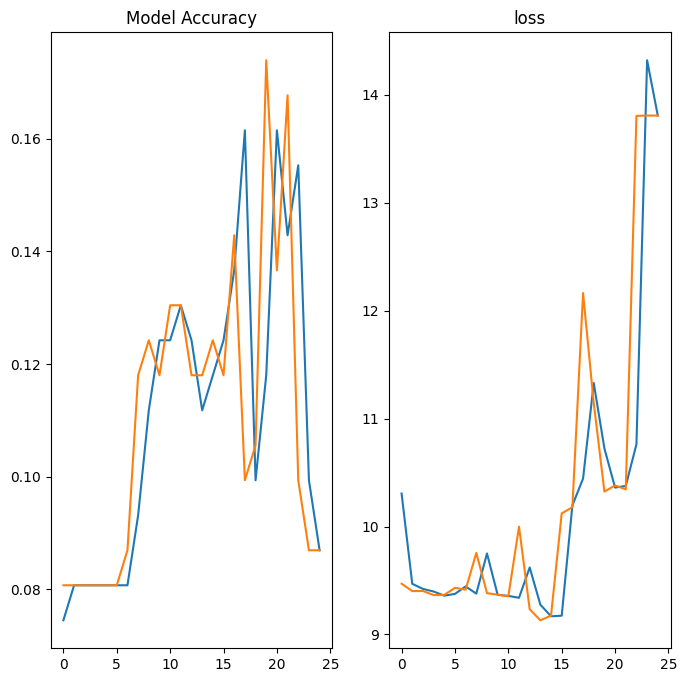

In [29]:
epochs_range = range(epochs_size)
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(epochs_range,history.history['accuracy'],label='train_acc')
plt.plot(epochs_range,history.history['val_accuracy'],label='val_acc')
plt.title('Model Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range,history.history['loss'],label='train_loss')
plt.plot(epochs_range,history.history['val_loss'],label='val_loss')
plt.title('loss')



In [47]:
image= r"C:\Users\manis\OneDrive\Desktop\food_image _classifi\Apple.jpg"
img = tf.keras.utils.load_img(image, target_size=(img_height, img_width))
img_array = tf.keras.utils.img_to_array(img)
img_batch = tf.expand_dims(img_array, 0)

In [48]:
predict = model.predict(img_batch)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step


In [51]:
score = tf.nn.softmax(predict)

In [56]:
print('Veg/Fruit in image is {} with accuracy of {:.2f}%'.format(
    data_cat[np.argmax(score)],
    np.max(score) * 100
))

Veg/Fruit in image is Meat with accuracy of 12.41%


In [54]:
model.save('image_classify.keras')